# **Advanced Analytics**

## **Objective**

The objective of this notebook is to perform advanced analytical techniques on the cleaned road accident dataset to uncover deeper patterns and relationships beyond standard KPI analysis. This notebook applies statistical methods, ranking, cumulative analysis, correlation analysis, pivot tables, crosstab analysis, quartile segmentation, Pareto analysis, and other advanced Pandas operations to identify high-risk locations, accident trends, and critical contributing factors. The insights generated in this notebook support more informed decision-making and provide a strong analytical foundation for the interactive dashboard and future predictive modeling.

# **Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# **Dataset upload**

In [ ]:
df = pd.read_csv('/content/cleaned_road_accident.csv')
df.head()

,accident_id,city,state,latitude,longitude,date,time,hour,day_of_week,is_weekend,...,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score,severity_index,risk_quartile
0,0,Pune,Maharashtra,18.680826,73.93039,2023-10-22,5:00,5,Sunday,Weekend,...,high,weather,fatal,2,2,Non Peak Hour,No Festival,0.85,4,Q4
1,1,Mumbai,Maharashtra,18.817732,72.79085,2023-05-21,4:00,4,Sunday,Weekend,...,low,weather,major,4,3,Non Peak Hour,No Festival,0.10,12,Q1
2,2,Mumbai,Maharashtra,19.096890,72.81943,2024-07-10,13:00,13,Wednesday,Weekday,...,medium,weather,minor,1,1,Non Peak Hour,No Festival,0.45,1,Q2
3,3,Chandigarh,Punjab,30.787806,76.84750,2025-03-30,11:00,11,Sunday,Weekend,...,high,distraction,minor,5,2,Non Peak Hour,No Festival,0.65,10,Q4
4,4,Chennai,Tamil Nadu,12.965155,80.28331,2024-01-25,16:00,16,Thursday,Weekday,...,low,distraction,minor,2,1,Non Peak Hour,No Festival,0.10,2,Q1


**Q1. Which 20% of cities contribute to approximately 80% of fatal accidents? (Pareto Analysis)**

In [ ]:
fatal_df = df[df['accident_severity'] == 'fatal']

city_fatal = (
    fatal_df.groupby('city')
    .agg(
        fatal_accidents=('accident_severity', 'count')
    )
    .reset_index()
    .sort_values(by='fatal_accidents', ascending=False)
)

city_fatal['cumulative_fatal_accidents'] = (
    city_fatal['fatal_accidents'].cumsum()
)

city_fatal['cumulative_percentage'] = (
    city_fatal['cumulative_fatal_accidents']
    / city_fatal['fatal_accidents'].sum()
    * 100
).round(2)

pareto_analysis = city_fatal[city_fatal['cumulative_percentage']<=80]

pareto_analysis

,city,fatal_accidents,cumulative_fatal_accidents,cumulative_percentage
7,Pune,398,398,13.32
0,Bangalore,384,782,26.18
3,Delhi,382,1164,38.97
1,Chandigarh,378,1542,51.62
5,Kolkata,377,1919,64.25
2,Chennai,371,2290,76.67


**Pareto Chart**

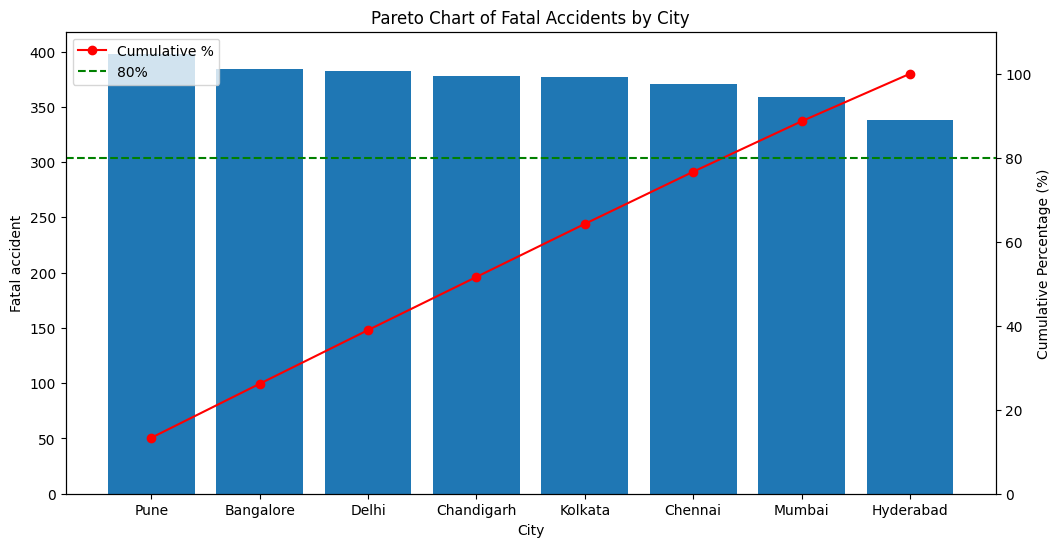

In [ ]:
fig,ax1 = plt.subplots(figsize=(12,6))

ax1.bar(
    city_fatal['city'],
    city_fatal['fatal_accidents']
)

ax1.set_xlabel('City')
ax1.set_ylabel('Fatal accident')


ax2 = ax1.twinx()

ax2.plot(
    city_fatal['city'],
    city_fatal['cumulative_percentage'],
    color = 'red',
    marker = 'o',
    label='Cumulative %'
)

ax2.set_ylabel("Cumulative Percentage (%)")
ax2.set_ylim(0, 110)

ax2.axhline(
    y=80,
    color='green',
    linestyle = '--',
    label='80%'

)

plt.title("Pareto Chart of Fatal Accidents by City")

ax2.legend()

plt.show()

**Risk Segmentation**


---


**Q2.classify every accident into different risk levels so that safety measures can be prioritized.**

In [ ]:
conditions = [
    df['risk_score'] < 0.33,
    ( df['risk_score'] >= 0.33) & (df['risk_score'] < 0.66),
    df['risk_score'] >= 0.66
]

choices = [
    'Low Risk',
    'Medium Risk',
    'High Risk'
]

df['risk_category'] = np.select(
    conditions,
    choices,
    default='Unknown'

)


risk_seg = df.groupby('risk_category').agg(
    total_accident = ('accident_severity','count'),
).reset_index()

risk_seg['percentage'] =  ((risk_seg['total_accident'] / df.shape[0])*100).round(2)

risk_seg

,risk_category,total_accident,percentage
0,High Risk,2070,10.35
1,Low Risk,6936,34.68
2,Medium Risk,10994,54.97


**Q3. ranking states based on a Severity Index**

In [ ]:
result = (df.groupby('state').agg(
          total_accidents = ('accident_id','count'),
          average_severity_index = ('severity_index','mean'),
          average_risk_score = ('risk_score','mean'),
          average_casualties = ('casualties','mean')
          ).round({'average_severity_index':2,
         'average_risk_score':2,
         'average_casualties':2})
         .sort_values(by='average_severity_index',ascending=False).reset_index())
result

,state,total_accidents,average_severity_index,average_risk_score,average_casualties
0,Tamil Nadu,2575,6.54,0.44,1.77
1,West Bengal,2559,6.53,0.43,1.76
2,Maharashtra,5009,6.38,0.44,1.74
3,Delhi,2433,6.27,0.44,1.72
4,Punjab,2577,6.19,0.44,1.70
5,Karnataka,2438,6.16,0.44,1.69
6,Telangana,2409,6.16,0.44,1.68


**Q4. Multi-Level Risk Ranking**

---


In [ ]:
state_city_accident = df.groupby(['state','city']).agg(
     total_accidents = ('accident_id','count'),
     average_severity_index = ('severity_index','mean'),
     average_risk_score = ('risk_score','mean'),
).round({'average_severity_index':2,
         'average_risk_score':2,
        }).reset_index()

state_city_fatal_accident = (df[df['accident_severity'] == 'fatal'].
       groupby(['state','city']).agg(
           fatal_accidents = ('accident_id','count')
       ).reset_index()
       )

state_city_accident_table = pd.merge(state_city_accident,state_city_fatal_accident,
                                     on=['state','city'],how='left')

state_city_accident_table['fatal_accidents'] = (
    state_city_accident_table['fatal_accidents']
    .fillna(0)
    .astype(int)
)

result = state_city_accident_table.sort_values(by=['state','fatal_accidents','average_severity_index'],ascending=[True,False,False])
result

,state,city,total_accidents,average_severity_index,average_risk_score,fatal_accidents
0,Delhi,Delhi,2433,6.27,0.44,382
1,Karnataka,Bangalore,2438,6.16,0.44,384
3,Maharashtra,Pune,2517,6.42,0.44,398
2,Maharashtra,Mumbai,2492,6.33,0.43,359
4,Punjab,Chandigarh,2577,6.19,0.44,378
5,Tamil Nadu,Chennai,2575,6.54,0.44,371
6,Telangana,Hyderabad,2409,6.16,0.44,338
7,West Bengal,Kolkata,2559,6.53,0.43,377


**Q5. Within each state, what is the rank of each city based on the number of fatal accidents?**

In [ ]:
state_city_fatal_accident = (df[df['accident_severity'] == 'fatal'].
       groupby(['state','city']).agg(
           fatal_accidents = ('accident_id','count')
       ).reset_index()
       )
state_city_fatal_accident['city_rank'] = state_city_fatal_accident .groupby('state')['fatal_accidents'].rank(ascending=False,method='dense').astype(int)
state_city_fatal_accident

,state,city,fatal_accidents,city_rank
0,Delhi,Delhi,382,1
1,Karnataka,Bangalore,384,1
2,Maharashtra,Mumbai,359,2
3,Maharashtra,Pune,398,1
4,Punjab,Chandigarh,378,1
5,Tamil Nadu,Chennai,371,1
6,Telangana,Hyderabad,338,1
7,West Bengal,Kolkata,377,1


**Q9. identify the highest-risk states based on their average risk score.**

In [ ]:
result = (df.groupby('state').agg(
          total_accidents = ('accident_id','count'),
          average_risk_score = ('risk_score','mean'),
          ).round({
         'average_risk_score':2,
          }).reset_index()
)
result['state_rank'] = result['average_risk_score'].rank(ascending=False,method='dense').astype(int)
result = result.sort_values(by='state_rank',ascending=True)
result

,state,total_accidents,average_risk_score,state_rank
0,Delhi,2433,0.44,1
1,Karnataka,2438,0.44,1
2,Maharashtra,5009,0.44,1
3,Punjab,2577,0.44,1
4,Tamil Nadu,2575,0.44,1
5,Telangana,2409,0.44,1
6,West Bengal,2559,0.43,2


**Fatality Rate Analysis**

---



**Q10. Which states have the highest percentage of fatal accidents?**

In [ ]:
state_accident = (df.groupby('state').agg(
                 total_accidents = ('accident_id','count')).reset_index()
)

state_fatal_accident = (df[df['accident_severity'] == 'fatal'].
       groupby('state').agg(
           fatal_accidents = ('accident_id','count')
       ).reset_index()
       )

state_table = pd.merge(state_accident,state_fatal_accident,on='state',how='left')
state_table['fatal_accidents'] = state_table['fatal_accidents'].fillna(0).astype(int)
state_table['fatality_rate'] = ((state_table['fatal_accidents'] / state_table['total_accidents'])*100).round(2)
state_table.sort_values(by='fatality_rate',ascending=False)

,state,total_accidents,fatal_accidents,fatality_rate
1,Karnataka,2438,384,15.75
0,Delhi,2433,382,15.70
2,Maharashtra,5009,757,15.11
6,West Bengal,2559,377,14.73
3,Punjab,2577,378,14.67
4,Tamil Nadu,2575,371,14.41
5,Telangana,2409,338,14.03


**Q11. Severity Distribution by State**

In [ ]:
(pd.crosstab(df['state'],df['accident_severity'],normalize='index')*100).round(2).reset_index()

accident_severity,state,fatal,major,minor
0,Delhi,15.70,28.40,55.90
1,Karnataka,15.75,29.00,55.25
2,Maharashtra,15.11,30.49,54.40
3,Punjab,14.67,30.27,55.06
4,Tamil Nadu,14.41,30.83,54.76
5,Telangana,14.03,31.22,54.75
6,West Bengal,14.73,28.80,56.47


**Q12. Weather Risk Index**

In [ ]:
weather_accident = df.groupby('weather').agg(
     total_accidents = ('accident_id','count'),
     average_risk_score = ('risk_score','mean'),
     average_severity_index = ('severity_index','mean'),
).round({'average_severity_index':2,
         'average_risk_score':2,
        }).reset_index()


weather_fatal_accident = (df[df['accident_severity'] == 'fatal'].
       groupby('weather').agg(
           fatal_accidents = ('accident_id','count')
       ).reset_index()
       )


weather_accident_table = pd.merge(weather_accident,weather_fatal_accident,
                                     on='weather',how='left')

weather_accident_table['fatal_accidents'] = (
    weather_accident_table['fatal_accidents']
    .fillna(0)
    .astype(int)
)

weather_accident_table['weather_risk_index'] = (weather_accident_table['average_risk_score'] * weather_accident_table['average_severity_index']
).round(2)
result = weather_accident_table.sort_values(by='weather_risk_index',ascending=False)
result

,weather,total_accidents,average_risk_score,average_severity_index,fatal_accidents,weather_risk_index
1,fog,6633,0.59,6.28,995,3.71
2,rain,6677,0.49,6.40,1000,3.14
0,clear,6690,0.24,6.29,992,1.51


**Q13. Cause Impact Score**

---

**identify which accident causes are the most dangerous, considering both frequency and severity**

In [ ]:
cause_accident = df.groupby('cause').agg(
     total_accidents = ('accident_id','count'),
     average_risk_score = ('risk_score','mean'),
     average_severity_index = ('severity_index','mean'),
).round({'average_severity_index':2,
         'average_risk_score':2,
        }).reset_index()


cause_fatal_accident = (df[df['accident_severity'] == 'fatal'].
       groupby('cause').agg(
           fatal_accidents = ('accident_id','count')
       ).reset_index()
       )


cause_accident_table = pd.merge(cause_accident,cause_fatal_accident,
                                     on='cause',how='left')

cause_accident_table['fatal_accidents'] = (
    cause_accident_table['fatal_accidents']
    .fillna(0)
    .astype(int)
)

cause_accident_table['cause_impact_score'] = (cause_accident_table['total_accidents'] * cause_accident_table['average_severity_index']
).round(2)
result = cause_accident_table.sort_values(by='cause_impact_score',ascending=False)
result

,cause,total_accidents,average_risk_score,average_severity_index,fatal_accidents,cause_impact_score
2,overspeeding,4025,0.44,6.33,603,25478.25
4,weather,3997,0.44,6.37,601,25460.89
3,poor road,3974,0.44,6.39,623,25393.86
0,distraction,4026,0.43,6.26,542,25202.76
1,drunk driving,3978,0.44,6.28,618,24981.84


**Q14. Peak Hour Severity Index**

---

**Are peak-hour accidents actually more severe than non-peak-hour accidents?**

In [ ]:
is_peak_hour_accident = df.groupby('is_peak_hour').agg(
     total_accidents = ('accident_id','count'),
     average_risk_score = ('risk_score','mean'),
     average_severity_index = ('severity_index','mean'),
     average_casualties = ('casualties','mean')
).round({'average_severity_index':2,
         'average_risk_score':2,
         'average_casualties':2
        }).reset_index()


is_peak_hour_fatal_accident = (df[df['accident_severity'] == 'fatal'].
       groupby('is_peak_hour').agg(
           fatal_accidents = ('accident_id','count')
       ).reset_index()
       )


is_peak_hour_accident_table = pd.merge(is_peak_hour_accident,is_peak_hour_fatal_accident,
                                     on='is_peak_hour',how='left')

is_peak_hour_accident_table['fatal_accidents'] = (
    is_peak_hour_accident_table['fatal_accidents']
    .fillna(0)
    .astype(int)
)

is_peak_hour_accident_table['peak_hour_severity_index'] = (is_peak_hour_accident_table['average_risk_score'] * is_peak_hour_accident_table['average_severity_index']
).round(2)
result = is_peak_hour_accident_table.sort_values(by='peak_hour_severity_index',ascending=False)
result

,is_peak_hour,total_accidents,average_risk_score,average_severity_index,average_casualties,fatal_accidents,peak_hour_severity_index
1,Peak Hour,4948,0.60,6.4,1.74,740,3.84
0,Non Peak Hour,15052,0.38,6.3,1.72,2247,2.39


**Q15. Risk Score Quartile Analysis**

In [ ]:
df.groupby('risk_quartile',observed=True).agg(
     total_accidents = ('accident_id','count'),
     average_severity_index = ('severity_index','mean'),
     average_casualties = ('casualties','mean')
).round({'average_severity_index':2,
         'average_casualties':2
        }).reset_index().sort_values(by='risk_quartile',ascending=True)

,risk_quartile,total_accidents,average_severity_index,average_casualties
0,Q1,5272,5.50,1.50
1,Q2,8361,6.06,1.66
2,Q3,1557,6.53,1.79
3,Q4,4810,7.63,2.08


**Q16.Risk Hotspot Score**

In [ ]:
state_accident = (df.groupby('state').agg(
                  total_accidents = ('accident_id','count'),
                  average_severity_index = ('severity_index','mean'),
                  average_risk_score = ('risk_score','mean')).round({'average_severity_index':2,
         'average_risk_score':2
        }).reset_index()
)

state_accident['risk_hotspot_score'] = (state_accident['total_accidents']*state_accident['average_risk_score']).round(2)
state_accident.sort_values(by='risk_hotspot_score',ascending=False)

,state,total_accidents,average_severity_index,average_risk_score,risk_hotspot_score
2,Maharashtra,5009,6.38,0.44,2203.96
3,Punjab,2577,6.19,0.44,1133.88
4,Tamil Nadu,2575,6.54,0.44,1133.00
6,West Bengal,2559,6.53,0.43,1100.37
1,Karnataka,2438,6.16,0.44,1072.72
0,Delhi,2433,6.27,0.44,1070.52
5,Telangana,2409,6.16,0.44,1059.96


**Q17 Multi-Factor Safety Score**

In [ ]:
state_accident = df.groupby('state').agg(
     total_accidents = ('accident_id','count'),
     average_severity_index = ('severity_index','mean'),
     average_risk_score = ('risk_score','mean'),
     average_casualties = ('casualties','mean')
).round({'average_severity_index':2,
         'average_risk_score':2,
         'average_casualties':2
        }).reset_index()

state_fatal_accident = (df[df['accident_severity'] == 'fatal'].
       groupby('state').agg(
           fatal_accidents = ('accident_id','count')
       ).reset_index()
       )

state_accident_table = pd.merge(state_accident,state_fatal_accident,
                                     on='state',how='left')

state_accident_table['fatal_accidents'] = (
    state_accident_table['fatal_accidents']
    .fillna(0)
    .astype(int)
)

state_accident_table['safety_score'] = (
  state_accident_table['average_severity_index']*state_accident_table['average_risk_score']*state_accident_table['average_casualties']).round(2)

state_accident_table.sort_values(by='safety_score',ascending=False)


,state,total_accidents,average_severity_index,average_risk_score,average_casualties,fatal_accidents,safety_score
4,Tamil Nadu,2575,6.54,0.44,1.77,371,5.09
6,West Bengal,2559,6.53,0.43,1.76,377,4.94
2,Maharashtra,5009,6.38,0.44,1.74,757,4.88
0,Delhi,2433,6.27,0.44,1.72,382,4.75
3,Punjab,2577,6.19,0.44,1.70,378,4.63
1,Karnataka,2438,6.16,0.44,1.69,384,4.58
5,Telangana,2409,6.16,0.44,1.68,338,4.55


**Q18. Executive KPI Dashboard Table**

In [ ]:
state_accident = df.groupby('state').agg(
     total_accidents = ('accident_id','count'),
     average_severity_index = ('severity_index','mean'),
     average_risk_score = ('risk_score','mean'),
     average_casualties = ('casualties','mean')
).round({'average_severity_index':2,
         'average_risk_score':2,
         'average_casualties':2
        }).reset_index()

state_fatal_accident = (df[df['accident_severity'] == 'fatal'].
       groupby('state').agg(
           fatal_accidents = ('accident_id','count')
       ).reset_index()
       )

state_accident_table = pd.merge(state_accident,state_fatal_accident,
                                     on='state',how='left')

state_accident_table['fatal_accidents'] = (
    state_accident_table['fatal_accidents']
    .fillna(0)
    .astype(int)
)

state_accident_table['fatality_rate'] = ((state_accident_table['fatal_accidents'] / state_accident_table['total_accidents'])*100).round(2)
state_accident_table['risk_hotspot_score'] = (state_accident_table['total_accidents']*state_accident_table['average_risk_score']).round(2)

state_accident_table['safety_score'] = (
  state_accident_table['average_severity_index']*state_accident_table['average_risk_score']*state_accident_table['average_casualties']).round(2)

state_accident_table.sort_values(by='safety_score',ascending=False)


,state,total_accidents,average_severity_index,average_risk_score,average_casualties,fatal_accidents,fatality_rate,risk_hotspot_score,safety_score
4,Tamil Nadu,2575,6.54,0.44,1.77,371,14.41,1133.00,5.09
6,West Bengal,2559,6.53,0.43,1.76,377,14.73,1100.37,4.94
2,Maharashtra,5009,6.38,0.44,1.74,757,15.11,2203.96,4.88
0,Delhi,2433,6.27,0.44,1.72,382,15.70,1070.52,4.75
3,Punjab,2577,6.19,0.44,1.70,378,14.67,1133.88,4.63
1,Karnataka,2438,6.16,0.44,1.69,384,15.75,1072.72,4.58
5,Telangana,2409,6.16,0.44,1.68,338,14.03,1059.96,4.55


**Q19 Executive Priority Score**

In [ ]:
state_accident = df.groupby('state').agg(
     total_accidents = ('accident_id','count'),
     average_severity_index = ('severity_index','mean'),
     average_risk_score = ('risk_score','mean'),
     average_casualties = ('casualties','mean')
).round({'average_severity_index':2,
         'average_risk_score':2,
         'average_casualties':2
        }).reset_index()

state_fatal_accident = (df[df['accident_severity'] == 'fatal'].
       groupby('state').agg(
           fatal_accidents = ('accident_id','count')
       ).reset_index()
       )

state_accident_table = pd.merge(state_accident,state_fatal_accident,
                                     on='state',how='left')

state_accident_table['fatal_accidents'] = (
    state_accident_table['fatal_accidents']
    .fillna(0)
    .astype(int)
)

state_accident_table['fatality_rate'] = ((state_accident_table['fatal_accidents'] / state_accident_table['total_accidents'])*100).round(2)
state_accident_table['risk_hotspot_score'] = (state_accident_table['total_accidents']*state_accident_table['average_risk_score']).round(2)

state_accident_table['safety_score'] = (
state_accident_table['average_severity_index']*state_accident_table['average_risk_score']*state_accident_table['average_casualties']).round(2)

state_accident_table['executive_priority_score'] = (state_accident_table['risk_hotspot_score']*state_accident_table['fatality_rate']*state_accident_table['safety_score']).round(2)
state_accident_table['priority_rank'] = state_accident_table['executive_priority_score'].rank(ascending=False,method='dense').astype(int)

state_accident_table.sort_values(by='priority_rank')


,state,total_accidents,average_severity_index,average_risk_score,average_casualties,fatal_accidents,fatality_rate,risk_hotspot_score,safety_score,executive_priority_score,priority_rank
2,Maharashtra,5009,6.38,0.44,1.74,757,15.11,2203.96,4.88,162512.96,1
4,Tamil Nadu,2575,6.54,0.44,1.77,371,14.41,1133.00,5.09,83102.04,2
6,West Bengal,2559,6.53,0.43,1.76,377,14.73,1100.37,4.94,80069.74,3
0,Delhi,2433,6.27,0.44,1.72,382,15.70,1070.52,4.75,79834.03,4
1,Karnataka,2438,6.16,0.44,1.69,384,15.75,1072.72,4.58,77380.66,5
3,Punjab,2577,6.19,0.44,1.70,378,14.67,1133.88,4.63,77015.51,6
5,Telangana,2409,6.16,0.44,1.68,338,14.03,1059.96,4.55,67664.14,7


# 📊  **Summary – Advanced Analytics**

## 🎯 **Overview**

The Advanced Analytics phase extended the KPI and Business Analysis by applying advanced analytical techniques to uncover deeper accident patterns and generate actionable business insights. This notebook moved beyond descriptive statistics by using Pareto Analysis, ranking methods, risk segmentation, composite scoring, hotspot identification, and executive performance metrics to evaluate accident severity, risk, and priority across different states, cities, weather conditions, and accident causes.

---

## 🔍 **Major Analytical Findings**

### 📊 **Pareto Analysis**

- The Pareto Analysis showed that a small number of cities contribute to the majority of fatal accidents.
- **Pune (398)** recorded the highest number of fatal accidents, followed by **Bangalore (384)**, **Delhi (382)**, **Chandigarh (378)**, **Kolkata (377)**, and **Chennai (371)**.
- These six cities together accounted for approximately **76.67%** of cumulative fatal accidents, indicating that targeted safety measures in a few locations could significantly reduce overall fatalities.

---

### 🏆 **State & City Ranking**

- **Tamil Nadu** recorded the highest **Average Severity Index (6.54)**, closely followed by **West Bengal (6.53)**.
- **Maharashtra** reported the highest number of accidents (**5,009**) while maintaining a high Severity Index (**6.38**).
- Within Maharashtra, **Pune** ranked first in fatal accidents, while **Mumbai** ranked second.

---

### ⚠️ **Risk Segmentation**

- Accident records were grouped into four Risk Quartiles based on the calculated Risk Score.
- **Q2** contained the highest number of accidents (**8,361** records).
- **Q4** represented the highest-risk group, recording the highest **Average Severity Index (7.63)** and **Average Casualties (2.08)**.
- These findings indicate that higher-risk accidents generally involve greater severity and more casualties.

---

### 💀 **Fatality Rate Analysis**

- **Karnataka** recorded the highest Fatality Rate (**15.75%**), followed closely by **Delhi (15.70%)** and **Maharashtra (15.11%)**.
- The analysis demonstrated that states with the highest accident counts are not necessarily those with the highest fatality rates.

---

### 🌦️ **Weather Risk Analysis**

- **Fog** recorded the highest **Weather Risk Index (3.71)** despite having fewer accidents than clear weather.
- **Rain** ranked second with a Weather Risk Index of **3.14**.
- Although **Clear** weather reported the largest number of accidents, it recorded the lowest Weather Risk Index (**1.51**), suggesting that adverse weather conditions increase accident severity rather than accident frequency.

---

### 🚘 **Cause Impact Analysis**

- **Overspeeding** achieved the highest **Cause Impact Score (25,478.25)**, making it the most influential accident cause.
- **Poor Road Conditions** recorded the highest number of fatal accidents (**623**).
- **Driver Distraction** remained the most frequent accident cause but produced a lower impact score than overspeeding.

---

### ⏰ **Peak Hour Severity Analysis**

- Peak-hour accidents recorded a higher **Average Risk Score (0.60)** than non-peak hours (**0.38**).
- The **Peak Hour Severity Index (3.84)** was considerably higher than the Non-Peak Hour Severity Index (**2.39**).
- These findings suggest that accidents occurring during busy traffic periods are generally more severe.

---

### 🔥 **Risk Hotspot Analysis**

- **Maharashtra** achieved the highest **Risk Hotspot Score (2203.96)**, making it the highest-priority state for road safety improvements.
- **Punjab** and **Tamil Nadu** ranked next, indicating that these states also require focused infrastructure and safety interventions.

---

### ⭐ **Multi-Factor Safety Score**

- **Tamil Nadu** recorded the highest **Multi-Factor Safety Score (5.09)**.
- **West Bengal (4.94)** and **Maharashtra (4.88)** followed closely.
- The safety score combines multiple accident indicators into a single metric, providing a more comprehensive evaluation of road safety performance.

---

### 📋**Executive Priority Analysis**

- Executive Priority Scores ranked states using accident frequency, severity, fatalities, and hotspot scores simultaneously.
- **Maharashtra** emerged as the highest overall priority due to its exceptionally high accident count and Risk Hotspot Score.
- Composite scoring demonstrated that evaluating multiple indicators together provides a more reliable assessment than relying on accident count alone.

---

# 💡 **Overall Insights**

The Advanced Analytics phase revealed several important patterns that were not visible through descriptive analysis alone.

- 📍 A small number of cities contribute to the majority of fatal accidents.
- 🚦 Maharashtra remains the highest-priority state due to its large accident volume and hotspot score.
- 🏙️ Pune is the highest-priority city for fatal accident reduction.
- 🌫️ Fog creates the highest accident risk despite recording fewer accidents than clear weather.
- 🚗 Overspeeding is the most impactful accident cause, while poor road conditions contribute to the highest number of fatal accidents.
- ⚠️ High-risk accident groups consistently experience greater severity and higher casualty rates.
- 📊 Composite scoring methods provide a more balanced and reliable assessment of road safety than accident frequency alone.

---

# ✅ **Conclusion**

The Advanced Analytics phase successfully transformed raw accident records into strategic business intelligence by applying Pareto Analysis, ranking methods, risk segmentation, hotspot identification, composite scoring, and executive performance metrics. These techniques identified Maharashtra as the highest-priority state, Pune as the city with the greatest fatal accident burden, Karnataka as the state with the highest fatality rate, Tamil Nadu as the state with the highest Severity Index and Safety Score, Fog as the highest-risk weather condition, and Overspeeding as the most impactful accident cause. Together, these insights provide transportation authorities and policymakers with a strong analytical foundation for prioritizing road safety initiatives, allocating resources efficiently, and supporting future predictive analytics.